In [1]:
# Setup
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recsys.config import load_config, set_seed
from recsys import plots
cfg = load_config()
set_seed(cfg["seed"])
plots.set_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
import json
import shap
from sklearn.inspection import PartialDependenceDisplay
from recsys import pipeline as P, explain as XP, fairness as F, experiments as X, evaluate as E, eda
from recsys.data import load_dataset, history
from recsys.features import to_model_frame, SENSITIVE_FEATURES
ds = load_dataset(cfg)
trained = P.load_trained(cfg)
model, cols, cats = trained["models"]["lgbm_classifier"], trained["cols"], trained["cats"]
test, tx = P.load_week(cfg, cfg["weeks"]["test"])
test["score"] = model.predict_proba(to_model_frame(test, cols, cats))[:, 1]
test["top12"] = F.top_k_flags(test, "score", 12)
k = cfg["eval"]["k"]

,feature,mean_abs_shap
0,a_pop_1w,0.3187
1,ci_prodcode_count,0.1785
2,garment_group_name,0.1224
3,a_days_since_last,0.1219
4,a_trend,0.1127
5,c_days_since_last,0.1107
6,rep_days_since,0.1082
7,a_pop_2w,0.1080
8,n_sources,0.0892
9,ci_garment_share,0.0793


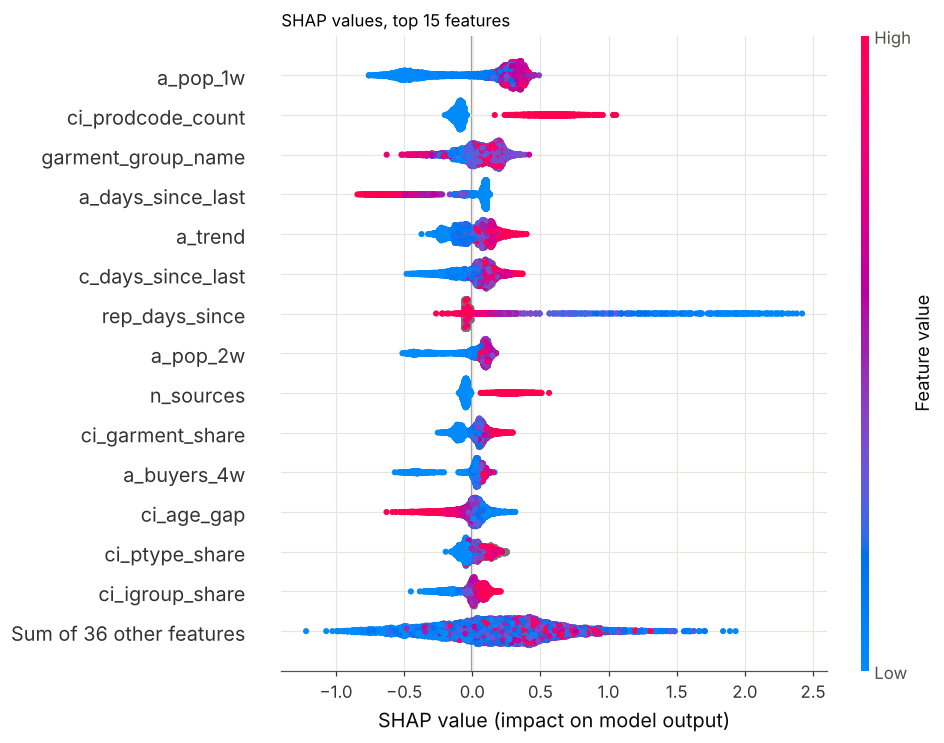

In [2]:
# 1. SHAP global importance (exact TreeSHAP from LightGBM, 6,000 test-week rows)
shap_rows = pd.concat([test[test["label"] == 1].sample(1000, random_state=cfg["seed"]), test[test["label"] == 0].sample(5000, random_state=cfg["seed"])])
exp, sample = XP.shap_explanation(model, shap_rows, cols, cats, n=len(shap_rows))
imp = XP.shap_importance(exp)
imp.to_csv(cfg["paths"]["tables"] / "shap_importance.csv", index=False)
plt.figure()
shap.plots.beeswarm(exp, max_display=15, show=False)
plt.title("SHAP values, top 15 features")
plots.save(plt.gcf(), "04_shap_beeswarm")
imp.head(15)

In [3]:
# 2. SHAP vs LightGBM gain importance
gain = XP.gain_importance(model, cols)
both = imp.merge(gain, on="feature")
both["shap_rank"] = both["mean_abs_shap"].rank(ascending=False)
both["gain_rank"] = both["gain"].rank(ascending=False)
both.head(12)

,feature,mean_abs_shap,gain,shap_rank,gain_rank
0,a_pop_1w,0.3187,0.0693,1.0000,2.0000
1,ci_prodcode_count,0.1785,0.0382,2.0000,5.0000
2,garment_group_name,0.1224,0.0394,3.0000,4.0000
3,a_days_since_last,0.1219,0.0099,4.0000,34.0000
4,a_trend,0.1127,0.0353,5.0000,6.0000
5,c_days_since_last,0.1107,0.0405,6.0000,3.0000
6,rep_days_since,0.1082,0.1440,7.0000,1.0000
7,a_pop_2w,0.1080,0.0282,8.0000,13.0000
8,n_sources,0.0892,0.0287,9.0000,11.0000
9,ci_garment_share,0.0793,0.0214,10.0000,20.0000


<Figure size 704x528 with 0 Axes>

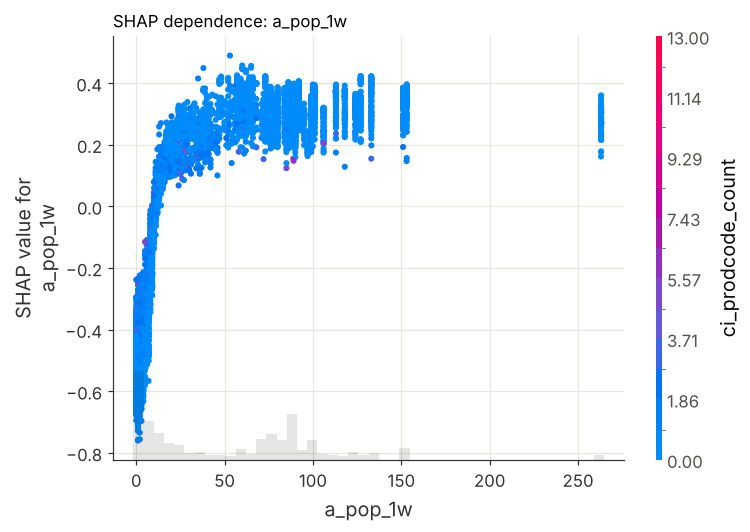

In [4]:
# 3. SHAP dependence for the top feature
top_feature = imp["feature"].iloc[0]
plt.figure()
shap.plots.scatter(exp[:, top_feature], color=exp[:, imp["feature"].iloc[1]], show=False)
plt.title(f"SHAP dependence: {top_feature}")
plots.save(plt.gcf(), "04_shap_dependence")

label of this item: 1 | predicted probability: 0.658


,feature,value,shap
0,rep_days_since,0.0000,2.4774
1,ci_prodcode_count,1.0000,0.7059
2,rep_rank,2.0000,0.4131
3,a_price_mean,0.2934,0.2325
4,c_n_articles,2.0000,0.2033
5,ci_ptype_share,1.0000,0.1887
6,garment_group_name,Outdoor,0.1799
7,c_price_mean,0.3034,0.1668


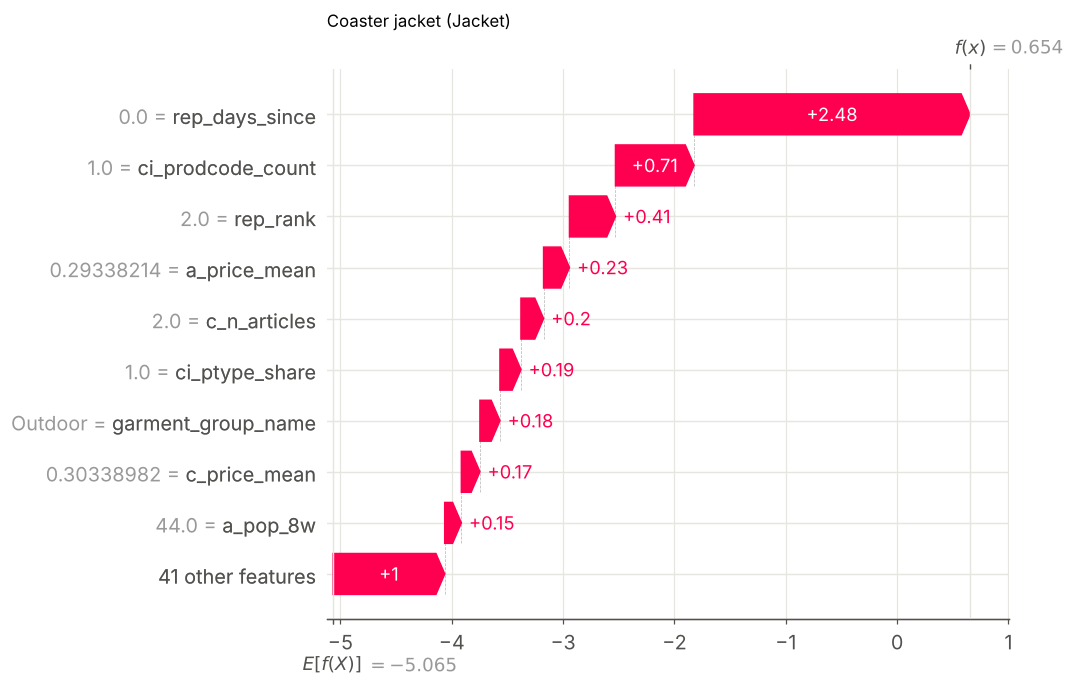

In [5]:
# 4. Local explanation: why one customer's #1 item was recommended
demo_cid = test[(test["label"] == 1) & (test["top12"] == 1)].sort_values("score", ascending=False)["cid"].iloc[0]
row = test[test["cid"] == demo_cid].sort_values("score", ascending=False).head(1)
local = XP.local_explanation(model, row, cols, cats, top=8)
print("label of this item:", int(row["label"].iloc[0]), "| predicted probability:", round(float(row["score"].iloc[0]), 3))
art = ds.articles.set_index("article_id").loc[row["article_id"].iloc[0]]
x_row = to_model_frame(row, cols, cats)
contrib = model.booster_.predict(x_row, pred_contrib=True)
exp1 = shap.Explanation(values=contrib[0, :-1], base_values=contrib[0, -1], data=row[cols].iloc[0].astype(str).to_numpy(), feature_names=cols)
plt.figure()
shap.plots.waterfall(exp1, max_display=10, show=False)
plt.title(f"{art['prod_name']} ({art['product_type_name']})")
plots.save(plt.gcf(), "04_shap_waterfall")
local

In [6]:
# 5. Partial dependence (PDP) and individual curves (ICE)
pdp_rows = to_model_frame(test.sample(1500, random_state=cfg["seed"]), cols, cats)
pdp_feats = [f for f in ["rep_days_since", "a_pop_1w", "a_trend"] if f in cols]
pdp_rows[pdp_feats] = pdp_rows[pdp_feats].astype("float64")
fig, axes = plt.subplots(1, len(pdp_feats), figsize=(12, 3.4))
PartialDependenceDisplay.from_estimator(model, pdp_rows, pdp_feats, kind="both", subsample=150, random_state=cfg["seed"], ax=axes, ice_lines_kw={"color": "#9fc0ea", "alpha": 0.25, "lw": 0.6}, pd_line_kw={"color": plots.ORANGE, "lw": 2.5})
fig.suptitle("PDP (orange) and ICE (blue) on predicted purchase probability", x=0.01, ha="left")
plots.save(fig, "04_pdp_ice")

In [7]:
# 6. Limitation check: leakage (history always ends before the target week)
leak = eda.check_leakage(ds, cfg)
leak

,target_week,target_start,history_last_day,history_first_day,no_overlap
0,0,2020-09-16,2020-09-15,2020-07-22,True
1,1,2020-09-09,2020-09-08,2020-07-15,True
2,2,2020-09-02,2020-09-01,2020-07-08,True
3,3,2020-08-26,2020-08-25,2020-07-01,True
4,4,2020-08-19,2020-08-18,2020-06-24,True


In [8]:
# 7. Limitation check: imbalance and overfitting
fit = pd.read_csv(cfg["paths"]["tables"] / "overfit_check.csv")
pd.Series({"test_positive_rate": test["label"].mean(), "negatives_per_positive": (1 - test["label"].mean()) / test["label"].mean(), "candidate_recall_ceiling": E.candidate_recall(test, tx["actual"]), "train_auc": fit.loc[fit["split"] == "train", "auc"].iloc[0], "test_auc": fit.loc[fit["split"] == "test", "auc"].iloc[0]})

test_positive_rate           0.0043
negatives_per_positive     233.4457
candidate_recall_ceiling     0.1118
train_auc                    0.8556
test_auc                     0.7584
dtype: float64

In [9]:
# 8. Fairness, customer side: recommendation quality by age band
pred = E.top_k_from_scores(test, "score", k)
per = E.per_customer_metrics(tx["actual"], pred, k, tx["popular"])
gq = F.group_quality(per, ds.customers, "age_band", cfg["fairness"]["di_threshold"], cfg["fairness"]["min_group_size"])
gq.to_csv(cfg["paths"]["tables"] / "fairness_age_band.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].bar(gq["age_band"].astype(str), gq["map12"], color=plots.BLUE, width=0.65)
axes[0].set_title("MAP@12 by age band")
axes[1].bar(gq["age_band"].astype(str), gq["disparate_impact"], color=[plots.RED if f else plots.AQUA for f in gq["di_flag"]], width=0.65)
axes[1].axhline(cfg["fairness"]["di_threshold"], color=plots.GRAY, ls="--", lw=1)
axes[1].set_title("Disparate impact of hit rate (dashed = 0.8 rule)")
axes[1].text(5, 0.05, f"n={int(gq.iloc[-1]['customers'])}", ha="center", fontsize=8, color=plots.GRAY)
plots.save(fig, "04_fairness_age")
gq

,age_band,customers,map12,recall12,ndcg12,hit_rate,share_of_customers,small_group,disparate_impact,di_flag
0,16-24,3824,0.0283,0.0641,0.0424,0.1198,0.2727,False,0.8075,False
1,25-34,4242,0.0283,0.0614,0.0433,0.1301,0.3025,False,0.8773,False
2,35-44,1467,0.0317,0.0626,0.0461,0.1309,0.1046,False,0.8823,False
3,45-54,2607,0.0335,0.0698,0.0497,0.1385,0.1859,False,0.9335,False
4,55+,1827,0.0382,0.0801,0.0552,0.1483,0.1303,False,1.0000,False
5,Unknown,56,0.0327,0.0625,0.0479,0.1071,0.0040,True,0.7223,False


In [10]:
# 9. Equalized odds and demographic parity (positive prediction = item makes the customer's top 12)
eo, eo_sum = F.equalized_odds(test, ds.customers, "top12", "age_band")
eo.to_csv(cfg["paths"]["tables"] / "equalized_odds_age_band.csv", index=False)
print(pd.Series(eo_sum))
eo

demographic_parity_difference   0.0119
selection_rate_ratio            0.9221
tpr_gap                         0.0890
fpr_gap                         0.0120
equalized_odds_difference       0.0890
dtype: float64


,age_band,selection_rate,tpr,fpr,positives
0,16-24,0.1526,0.4501,0.1514,1193
1,25-34,0.1441,0.4337,0.1428,1598
2,35-44,0.1407,0.4288,0.1394,555
3,45-54,0.1487,0.4749,0.1473,918
4,55+,0.1469,0.5176,0.1455,597
5,Unknown,0.1514,0.4286,0.1505,14


In [11]:
# 10. Fairness, item side: popularity bias in what we show
hist0 = history(ds.transactions, cfg["weeks"]["test"], cfg["weeks"]["history_weeks"])
tiers = F.popularity_tiers(hist0, cfg["fairness"]["long_tail_quantile"])
n_catalog = int(test["article_id"].nunique())
expo = pd.DataFrame({"ranker": F.exposure_report(pred, tx["actual"], tiers, n_catalog), "popularity_baseline": F.exposure_report(tx["per_source"]["popularity"], tx["actual"], tiers, n_catalog)})
expo.to_csv(cfg["paths"]["tables"] / "exposure_head_tail.csv")
expo

,ranker,popularity_baseline
head_share_of_slots,0.9529,1.0000
long_tail_share_of_slots,0.0471,0.0000
long_tail_share_of_purchases,0.3410,0.3410
distinct_items_recommended,"7,045.0000",12.0000
coverage,0.2902,0.0005
exposure_gini,0.8997,0.0000


In [12]:
# 11. Mitigation A: reweight training rows so every age band counts equally
train = P.load_train(cfg)
params, _ = X.best_params(cfg)
rounds = int(model.best_iteration_)
w = F.inverse_frequency_weights(train, ds.customers, "age_band")
m_rw = X.fixed_lgbm(train, cols, cats, params, rounds, cfg["seed"], weight=w)
pred_rw = X.scores_to_pred(test, m_rw.predict_proba(to_model_frame(test, cols, cats))[:, 1], k)
gq_rw = F.group_quality(E.per_customer_metrics(tx["actual"], pred_rw, k, tx["popular"]), ds.customers, min_size=cfg["fairness"]["min_group_size"])
gq_rw[["age_band", "customers", "map12", "hit_rate", "disparate_impact"]]

,age_band,customers,map12,hit_rate,disparate_impact
0,16-24,3824,0.0284,0.1169,0.8120
1,25-34,4242,0.0268,0.1264,0.8778
2,35-44,1467,0.0310,0.1357,0.9423
3,45-54,2607,0.0329,0.1373,0.9539
4,55+,1827,0.0386,0.1440,1.0000
5,Unknown,56,0.0382,0.1071,0.7443


In [13]:
# 12. Mitigation B: fairness through unawareness (drop age and age-derived features)
cols_blind = [c for c in cols if c not in SENSITIVE_FEATURES]
m_blind = X.fixed_lgbm(train, cols_blind, cats, params, rounds, cfg["seed"])
pred_blind = X.scores_to_pred(test, m_blind.predict_proba(to_model_frame(test, cols_blind, cats))[:, 1], k)
gq_blind = F.group_quality(E.per_customer_metrics(tx["actual"], pred_blind, k, tx["popular"]), ds.customers, min_size=cfg["fairness"]["min_group_size"])
gq_blind[["age_band", "customers", "map12", "hit_rate", "disparate_impact"]]

,age_band,customers,map12,hit_rate,disparate_impact
0,16-24,3824,0.0294,0.1190,0.8599
1,25-34,4242,0.0268,0.1273,0.9199
2,35-44,1467,0.0334,0.1384,1.0000
3,45-54,2607,0.0331,0.1366,0.9868
4,55+,1827,0.0365,0.1325,0.9572
5,Unknown,56,0.0389,0.1071,0.7743


In [14]:
# 13. Mitigation C: long-tail re-ranking (score percentile minus lambda x popularity percentile)
test["pop_1w"] = test["a_pop_1w"].fillna(0)
curve = F.tradeoff_curve(test, "score", "pop_1w", [0, 0.1, 0.2, 0.3, 0.5, 0.8], tx["actual"], tiers, k, tx["popular"], n_catalog)
curve.to_csv(cfg["paths"]["tables"] / "rerank_tradeoff.csv", index=False)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(curve["long_tail_share_of_slots"] * 100, curve["map@12"], color=plots.BLUE, marker="o", ms=5, lw=2)
[ax.annotate(f"λ={l}", (x * 100, y), textcoords="offset points", xytext=(5, 4), fontsize=8, color=plots.GRAY) for l, x, y in zip(curve["lambda"], curve["long_tail_share_of_slots"], curve["map@12"])]
ax.set_xlabel("Long-tail share of recommendation slots (%)")
ax.set_ylabel("MAP@12")
ax.set_title("Accuracy vs long-tail exposure")
plots.save(fig, "04_rerank_tradeoff")
curve[["lambda", "map@12", "hit_rate", "long_tail_share_of_slots", "coverage", "exposure_gini"]]

,lambda,map@12,hit_rate,long_tail_share_of_slots,coverage,exposure_gini
0,0.0000,0.0309,0.1312,0.0471,0.2902,0.8997
1,0.1000,0.0280,0.1295,0.0545,0.3182,0.8885
2,0.2000,0.0247,0.1264,0.0619,0.3419,0.8765
3,0.3000,0.0226,0.1229,0.0693,0.3631,0.8649
4,0.5000,0.0200,0.1150,0.0845,0.4090,0.8433
5,0.8000,0.0173,0.1024,0.1089,0.4763,0.8128


In [15]:
# 14. Mitigation summary (bands with fewer than 100 customers are reported but not used for the gap)
summary = pd.DataFrame([{"variant": "baseline ranker", **F.gap_summary(gq)}, {"variant": "A: reweighted age bands", **F.gap_summary(gq_rw)}, {"variant": "B: no age features", **F.gap_summary(gq_blind)}, {"variant": "C: re-rank, lambda 0.1", "map@12": curve.loc[curve["lambda"] == 0.1, "map@12"].iloc[0]}])
summary.to_csv(cfg["paths"]["tables"] / "mitigation_summary.csv", index=False)
summary

,variant,map@12,min_disparate_impact,map_gap_best_worst,lowest_band
0,baseline ranker,0.0309,0.8075,0.0099,16-24
1,A: reweighted age bands,0.0304,0.8120,0.0118,25-34
2,B: no age features,0.0307,0.8599,0.0096,25-34
3,"C: re-rank, lambda 0.1",0.0280,NaN,NaN,NaN
